# Gradient Descent Recover

We consider a convex and L-smooth function $f$ with a minimizer $x_\star$ satisfying $\nabla f(x_\star)=0$. The initial point satisfies $\|x_0-x_\star\| \le R$, and gradient descent uses the fixed step size $1/L$:

$$
x_{k+1}=x_k-\frac{1}{L}\nabla f(x_k),\qquad k=0,1,\ldots,N-1.
$$

The performance metric is

$$
f(x_N)-f(x_\star).
$$

The Block 1 numerical evidence below identifies the candidate worst-case rate

$$
f(x_N)-f(x_\star) \le \frac{L R^2}{4N+2}.
$$

## Proof Statement

### Theorem

Let $f$ be convex and $L$-smooth, and let $x_{\star}$ satisfy $\nabla f(x_{\star})=0$. For gradient descent

$$
x_{k+1}=x_k-\frac{1}{L}\nabla f(x_k),
$$

with $\|x_0-x_{\star}\|\le R$, define for $1\le k<N$

$$
V_k = \frac{k+1}{2N-k}\bigl(f(x_k)-f(x_{\star})\bigr)
-\frac{L}{4N+2}\|x_0-x_{\star}\|^2
-\frac{k+1}{2L(2N-k)}\|\nabla f(x_k)\|^2
+\frac{L(2N-2k-1)}{2(2N-k)^2}\|x_{k+1}-x_{\star}\|^2.
$$

The terminal certificate is

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2.
$$

Then

$$
f(x_N)-f(x_{\star})\le \frac{L R^2}{4N+2}.
$$

### Proof outline

For smooth convex interpolation, use the residual

$$
I_f(u,v)=f(v)-f(u)-\langle \nabla f(u),v-u\rangle-\frac{1}{2L}\|\nabla f(v)-\nabla f(u)\|^2\le 0.
$$

Let

$$
\lambda_{k,k+1}=\frac{k+1}{2N-k},\qquad
\lambda_{\star,k+1}=\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k},
$$

and

$$
\sigma_k=\frac{4Nk+6N-2k^2-4k-1}{2(2N-k-1)^2}.
$$

For $1\le k<N-1$, the one-step identity is

$$
V_{k+1}-V_k = \lambda_{k,k+1} I_f(x_k,x_{k+1})
+\lambda_{\star,k+1} I_f(x_{\star},x_{k+1})
-L\sigma_k\left\|\frac{x_{k+1}-x_{\star}}{2N-k}-\frac{1}{L}\nabla f(x_{k+1})\right\|^2\le 0.
$$

The base identity is

$$
V_1=\lambda_{\star,0}I_f(x_{\star},x_0)+\lambda_{0,1}I_f(x_0,x_1)
+\lambda_{\star,1}I_f(x_{\star},x_1)-L\delta_0\|z_0\|^2
-L\sigma_0\left\|\frac{x_1-x_{\star}}{2N}-\frac{1}{L}\nabla f(x_1)\right\|^2\le 0,
$$

where $\lambda_{\star,0}=\lambda_{0,1}=1/(2N)$, $\delta_0=(2N+1)/(8N^2)$, and

$$
z_0=\frac{x_0-x_{\star}}{2N+1}-\frac{1}{L}\nabla f(x_0).
$$

Thus $V_N\le 0$. The boundary identity gives

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2,
$$

so $f(x_N)-f(x_{\star})\le L\|x_0-x_{\star}\|^2/(4N+2)\le LR^2/(4N+2)$.

## Imports

In [1]:
import importlib.util
import itertools
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pepflow").exists():
    REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pepflow as pf  # noqa: E402
import sympy as sp  # noqa: E402

from pepflow.lyapunov_utils import (  # noqa: E402
    find_symmetric_coefficient_matrix,
    ldl_decompose_with_reversed_basis,
    select_independent_subset,
    vectors_in_column_space,
)

STATE_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_b1.json"

## Function and Parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f"], L=L)

## PEP Setup

In [3]:
def make_ctx_gd_recover(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    f.set_stationary_point("x_star")

    for k in range(int(N)):
        x = x - (1 / L) * f.grad(x)
        x.add_tag(f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    ctx = make_ctx_gd_recover(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(f(ctx[f"x_{N}"]) - f(ctx["x_star"]))
    return ctx, pb, f

## Numerical Evidence

N=1: PEP=0.1666664722, candidate=0.1666666667
N=2: PEP=0.0999977883, candidate=0.1000000000
N=3: PEP=0.0714295812, candidate=0.0714285714
N=4: PEP=0.0555556260, candidate=0.0555555556
N=5: PEP=0.0454541392, candidate=0.0454545455
N=6: PEP=0.0384616779, candidate=0.0384615385
N=7: PEP=0.0333332780, candidate=0.0333333333


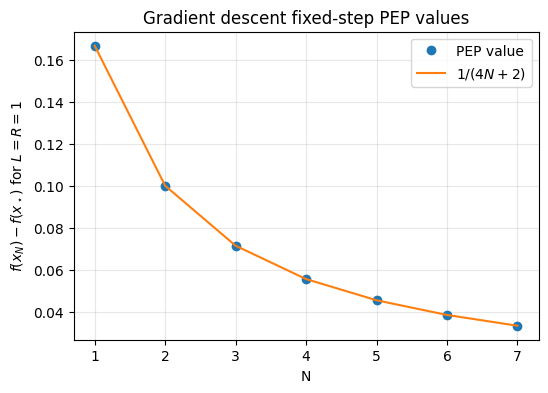

In [4]:
with STATE_PATH.open(encoding="utf-8") as fh:
    state = json.load(fh)

Ns = [item["N"] for item in state["sweep_results"]]
pep_values = [item["opt_value"] for item in state["sweep_results"]]
rate_values = [1 / (4 * N + 2) for N in Ns]

for N, value, rate in zip(Ns, pep_values, rate_values):
    print(f"N={N}: PEP={value:.10f}, candidate={rate:.10f}")

plt.figure(figsize=(6, 4))
plt.plot(Ns, pep_values, "o", label="PEP value")
plt.plot(Ns, rate_values, "-", label=r"$1/(4N+2)$")
plt.xlabel("N")
plt.ylabel(r"$f(x_N)-f(x_\star)$ for $L=R=1$")
plt.title("Gradient descent fixed-step PEP values")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Dense and Relaxed Proof Solves

At `N_VERIFY = 4`, the dense solve matches the recovered rate. The sparse relaxation keeps only the consecutive interpolation inequalities and the star-row inequalities; the optimum is preserved to solver tolerance.

In [5]:
B2_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_b2.json"
DENSE_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_dense.json"
RELAXED_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_relaxed.json"

with B2_PATH.open(encoding="utf-8") as fh:
    b2 = json.load(fh)
with DENSE_PATH.open(encoding="utf-8") as fh:
    dense = json.load(fh)
with RELAXED_PATH.open(encoding="utf-8") as fh:
    relaxed = json.load(fh)

N_int = b2["N_verify"]
print(f"N_VERIFY={N_int}")
print(f"dense objective:   {dense['opt_value']:.10f}")
print(f"relaxed objective: {relaxed['opt_value']:.10f}")
print(f"candidate rate:    {1 / (4 * N_int + 2):.10f}")
print(f"preserved optimum: {abs(dense['opt_value'] - relaxed['opt_value']) < 1e-5}")
print("basis vectors:", relaxed["basis_vectors"])

N_VERIFY=4
dense objective:   0.0555556260
relaxed objective: 0.0555555483
candidate rate:    0.0555555556
preserved optimum: True
basis vectors: ['x_0', 'x_star', 'grad_f(x_0)', 'grad_f(x_1)', 'grad_f(x_2)', 'grad_f(x_3)', 'grad_f(x_4)']


In [6]:
print("Active interpolation inequalities:")
for name in b2["active_constraints"]:
    if name != "f:x_star,x_star":
        print(" ", name)
print(f"Dropped constraints: {len(b2['relaxed_constraints'])}")

Active interpolation inequalities:
  f:x_0,x_1
  f:x_1,x_2
  f:x_2,x_3
  f:x_3,x_4
  f:x_star,x_0
  f:x_star,x_1
  f:x_star,x_2
  f:x_star,x_3
  f:x_star,x_4
Dropped constraints: 26


In [7]:
print("Relaxed lambda certificate:")
pf.pprint_labeled_matrix(
    np.array(b2["lambda_matrix"], dtype=float),
    b2["lambda_row_names"],
    b2["lambda_col_names"],
)
print("Relaxed S certificate:")
pf.pprint_labeled_matrix(
    np.array(b2["S_matrix"], dtype=float),
    b2["S_row_names"],
    b2["S_col_names"],
)

Relaxed lambda certificate:


<IPython.core.display.Math object>

Relaxed S certificate:


<IPython.core.display.Math object>

## Closed-Form Lambda Certificate

For tags `x_i` and `x_j`, with `x_star` indexed as `N+1`, the nonzero entries are the consecutive row entries and the star-row entries induced by their differences.

In [8]:
def tag_to_index(tag, N=N_int):
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return 1 - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


row_names = b2["lambda_row_names"]
col_names = b2["lambda_col_names"]
lambda_cand = pf.pprint_labeled_matrix(lamb, row_names, col_names, return_matrix=True)
if lambda_cand is None:
    raise RuntimeError("lambda matrix construction failed")
print(
    "max lambda residual:",
    max(
        abs(float(lambda_cand[i, j]) - b2["lambda_matrix"][i][j])
        for i in range(len(row_names))
        for j in range(len(col_names))
    ),
)

<IPython.core.display.Math object>

max lambda residual: 6.257644294405118e-08


## S Decomposition

The relaxed Gram dual matrix decomposes into five squared vectors for `N=4`. The later Lyapunov steps will recover the general closed-form coefficient sequence.

In [9]:
params_sp = {"L": sp.S(1), "R": sp.S(1)}
spec = importlib.util.spec_from_file_location(
    "gd_recover_setup", str(REPO_ROOT / "examples_peppy/gd_recover/gd_recover_setup.py")
)
if spec is None or spec.loader is None:
    raise ImportError("Cannot load gd_recover_setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)
ctx_prf, pb_prf, obj_prf = setup.get_pep_setup(sp.S(N_int), params_sp)
pb_prf.set_relaxed_constraints(b2["relaxed_constraints"])
result_prf = pb_prf.solve(resolve_parameters=params_sp)
S_sol = result_prf.get_gram_dual_matrix()
D, ell = ldl_decompose_with_reversed_basis(
    S_sol, ctx_prf.basis_vectors(), print_output=False
)

print("LDL diagonal:", [round(float(D[i, i]), 10) for i in range(D.shape[0])])
print("Rationalized delta:", b2["S_delta"])
for item in ell[: N_int + 1]:
    print(item)

c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




LDL diagonal: [0.5000000005, 0.7800000752, 0.4583333771, 0.234693892, 0.0703124974, -0.0, 0.0]
Rationalized delta: ['9/128', '23/98', '11/24', '39/50', '1/2']
1*grad_f(x_4)+0.2*grad_f(x_3)+0.2*grad_f(x_2)+0.2*grad_f(x_1)+0.2*grad_f(x_0)+0.2*x_star+-0.2*x_0
0*grad_f(x_4)+1*grad_f(x_3)+0.1667*grad_f(x_2)+0.1667*grad_f(x_1)+0.1667*grad_f(x_0)+0.1667*x_star+-0.1667*x_0
0*grad_f(x_4)+0*grad_f(x_3)+1*grad_f(x_2)+0.1429*grad_f(x_1)+0.1429*grad_f(x_0)+0.1429*x_star+-0.1429*x_0
0*grad_f(x_4)+0*grad_f(x_3)+0*grad_f(x_2)+1*grad_f(x_1)+0.125*grad_f(x_0)+0.125*x_star+-0.125*x_0
0*grad_f(x_4)+0*grad_f(x_3)+0*grad_f(x_2)+0*grad_f(x_1)+1*grad_f(x_0)+0.1111*x_star+-0.1111*x_0


In [10]:
L = setup.L
f = setup.f
x = [ctx_prf[f"x_{i}"] for i in range(N_int + 1)]
x_star = ctx_prf["x_star"]
pm = pf.ExpressionManager(ctx_prf, resolve_parameters=params_sp)

delta = [
    sp.Rational(9, 128),
    sp.Rational(23, 98),
    sp.Rational(11, 24),
    sp.Rational(39, 50),
    sp.Rational(1, 2),
]
S_guess = pf.Scalar.zero()
for i, coeff_i in enumerate(delta):
    z_i = (x[i] - x_star) / sp.S(2 * N_int + 1 - i) - (1 / L) * f.grad(x[i])
    S_guess += L * coeff_i * z_i**2

S_residual = S_sol.matrix - pm.eval_scalar(S_guess).inner_prod_coords
pf.pprint_labeled_matrix(S_residual, S_sol.row_names, S_sol.col_names)
print("S matches:", np.allclose(S_residual, 0, atol=1e-5))

<IPython.core.display.Math object>

S matches: True


## Fixed-N Full Proof Identity

The certificate verifies

$$
f(x_N)-f(x_\star)-\frac{1}{4N+2}\|x_0-x_\star\|^2-\sum_{i,j}\lambda_{ij} I_{ij}+S=0
$$

for `N=4`, where `I_{ij}` denotes the smooth convex interpolation inequality exposed by PEPFlow.

In [11]:
interp_sum = pf.Scalar.zero()
for ri, ci in itertools.product(row_names, col_names):
    coeff = lamb(ri, ci, N_int)
    if coeff != 0:
        interp_sum += coeff * obj_prf.interp_ineq(ri, ci)

x_0 = ctx_prf["x_0"]
x_N = ctx_prf[f"x_{N_int}"]
tau = sp.Rational(1, 4 * N_int + 2)
LHS = obj_prf(x_N) - obj_prf(x_star) - tau * (x_0 - x_star) ** 2
proof_residual = LHS - interp_sum + S_guess
proof_matrix = pm.eval_scalar(proof_residual).inner_prod_coords
proof_funcs = pm.eval_scalar(proof_residual).func_coords

pf.pprint_labeled_matrix(proof_matrix, S_sol.row_names, S_sol.col_names)
print("function-coordinate residual:", proof_funcs)
print(
    "Proof valid:",
    np.allclose(proof_matrix, 0, atol=1e-5) and np.allclose(proof_funcs, 0, atol=1e-5),
)

<IPython.core.display.Math object>

function-coordinate residual: [0 0 -2.77555756156289e-17 2.77555756156289e-17 5.55111512312578e-17 0]
Proof valid: True


## Partial-Sum Lyapunov Construction and Rank Profile

The partial sums group the full-PEP certificate in chronological order. Let

$$
z_i=\frac{x_i-x_\star}{2N+1-i}-\frac{1}{L}\nabla f(x_i).
$$

The initialization uses the boundary pair and the first square term,

$$
V_0=0,\qquad \text{partial}=-L\delta_0\|z_0\|^2+\lambda_{\star,0}I_{\star,0}.
$$

Then each step appends

$$
V_{k+1}-V_k=\lambda_{k,k+1}I_{k,k+1}+\lambda_{\star,k+1}I_{\star,k+1}-L\delta_{k+1}\|z_{k+1}\|^2.
$$

For `N=4`, the interior ranks are constant, and the final partial sum is the rank-one boundary expression matching the recovered guarantee.

In [12]:
B3_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_b3.json"
with B3_PATH.open(encoding="utf-8") as fh:
    b3 = json.load(fh)

N_int = b3["N_verify"]
rank_tolerance = b3["rank_tolerance"]
row_names = b3["lambda_row_names"]
col_names = b3["lambda_col_names"]
print("extra duals:", b3["extra_duals"])
print("interpolation rows:", row_names)
print("interpolation cols:", col_names)

extra duals: {}
interpolation rows: ['x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_star']
interpolation cols: ['x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_star']


In [13]:
params_sp = {"L": sp.S(1), "R": sp.S(1)}
ctx_lyap, pb_lyap, obj_lyap = setup.get_pep_setup(sp.S(N_int), params_sp)
pb_lyap.set_relaxed_constraints(b3["relaxed_constraints"])
result_lyap = pb_lyap.solve(resolve_parameters=params_sp)
pm_lyap = pf.ExpressionManager(ctx_lyap, resolve_parameters=params_sp)

L = setup.L
f = setup.f
x = [ctx_lyap[f"x_{i}"] for i in range(N_int + 1)]
x_star = ctx_lyap["x_star"]
delta = [
    sp.Rational(9, 128),
    sp.Rational(23, 98),
    sp.Rational(11, 24),
    sp.Rational(39, 50),
    sp.Rational(1, 2),
]
z = [
    (x[i] - x_star) / sp.S(2 * N_int + 1 - i) - (1 / L) * f.grad(x[i])
    for i in range(N_int + 1)
]
print("delta:", delta)
print("z_i form: (x_i - x_star)/(2*N + 1 - i) - grad_f(x_i)/L")

c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



delta: [9/128, 23/98, 11/24, 39/50, 1/2]
z_i form: (x_i - x_star)/(2*N + 1 - i) - grad_f(x_i)/L


In [14]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
partial_sum -= L * delta[0] * z[0] ** 2
partial_sum += lamb("x_star", "x_0") * obj_lyap.interp_ineq("x_star", "x_0")

for step in range(N_int):
    partial_sum += lamb(f"x_{step}", f"x_{step + 1}") * obj_lyap.interp_ineq(
        f"x_{step}", f"x_{step + 1}"
    )
    partial_sum += lamb("x_star", f"x_{step + 1}") * obj_lyap.interp_ineq(
        "x_star", f"x_{step + 1}"
    )
    partial_sum -= L * delta[step + 1] * z[step + 1] ** 2
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm_lyap.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 3
rank V_2: 3
rank V_3: 3
rank V_4: 1
Interior rank is constant: True


In [15]:
x_0 = ctx_lyap["x_0"]
x_N = ctx_lyap[f"x_{N_int}"]
tau = sp.Rational(1, 4 * N_int + 2)
boundary = obj_lyap(x_N) - obj_lyap(x_star) - tau * (x_0 - x_star) ** 2
coverage_residual = lyap[N_int] - boundary
coverage_matrix = pm_lyap.eval_scalar(coverage_residual).inner_prod_coords.astype(float)
coverage_func = pm_lyap.eval_scalar(coverage_residual).func_coords.astype(float)
final_rank = int(
    np.linalg.matrix_rank(
        pm_lyap.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float),
        tol=rank_tolerance,
    )
)

print(f"lyap[{N_int}] rank:", final_rank)
print("coverage matrix residual:", np.max(np.abs(coverage_matrix)))
print("coverage function residual:", np.max(np.abs(coverage_func)))

lyap[4] rank: 1
coverage matrix residual: 2.7755575615628914e-17
coverage function residual: 0.0


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable vectors spanning each low-rank quadratic form. The interior terms have rank three, so we look for a three-vector template that moves with `k`; the terminal term is the rank-one boundary case.

In [16]:
B4_PATH = REPO_ROOT / "examples_peppy/gd_recover/state/gd_recover_b4.json"
with B4_PATH.open(encoding="utf-8") as fh:
    b4 = json.load(fh)

computed_ranks = []
for Vk in lyap:
    matrix = pm_lyap.eval_scalar(Vk).inner_prod_coords.astype(float)
    computed_ranks.append(int(np.linalg.matrix_rank(matrix, tol=rank_tolerance)))
print("stored rank profile:", b4["rank_profile"])
print("computed rank profile:", computed_ranks)

stored rank profile: [0, 3, 3, 3, 1]
computed rank profile: [0, 3, 3, 3, 1]


### Candidate-vector scan

Candidates include tagged iterates, gradient values, point-to-solution gaps, anchor gaps, and simple differences. Duplicates and zero vectors are skipped before testing column-space membership.

In [17]:
candidates = []
candidate_labels = []


def add_candidate(label, vector):
    coords = np.asarray(pm_lyap.eval_vector(vector).coords, dtype=float).reshape(-1)
    if np.linalg.norm(coords) < 1e-9:
        return
    for existing in candidates:
        old = np.asarray(pm_lyap.eval_vector(existing).coords, dtype=float).reshape(-1)
        if np.linalg.norm(coords - old) < 1e-9:
            return
    candidate_labels.append(label)
    candidates.append(vector)


for i in range(N_int + 1):
    add_candidate(f"x_{i}", ctx_lyap[f"x_{i}"])
    add_candidate(f"g_{i}", obj_lyap.grad(ctx_lyap[f"x_{i}"]))
    add_candidate(f"x_{i}-x_star", ctx_lyap[f"x_{i}"] - x_star)
add_candidate("x_star", x_star)
add_candidate("x_0-x_star", ctx_lyap["x_0"] - x_star)
for i in range(N_int + 1):
    add_candidate(f"x_{i}-x_0", ctx_lyap[f"x_{i}"] - ctx_lyap["x_0"])

base = list(candidates)
base_labels = list(candidate_labels)
for i, j in itertools.combinations(range(min(len(base), 16)), 2):
    add_candidate(f"{base_labels[i]} - {base_labels[j]}", base[i] - base[j])

print("candidate count:", len(candidates))

candidate count: 108


In [18]:
for k in range(1, N_int):
    in_col = vectors_in_column_space(
        lyap[k],
        candidates,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        rtol=1e-4,
        atol=1e-4,
    )
    print(f"V_{k} column-space candidates:")
    for vector in in_col:
        print("  ", candidate_labels[candidates.index(vector)])

V_1 column-space candidates:
   g_0
   x_0-x_star
   g_1
   x_1-x_star
   x_2-x_star
   x_1-x_0
   x_2-x_0
   x_0 - x_2
   g_0 - x_0-x_star
   g_0 - g_1
   g_0 - x_1-x_star
   g_0 - x_2-x_star
   x_0-x_star - g_1
   g_1 - x_1-x_star
   g_1 - x_2-x_star
V_2 column-space candidates:
   x_0-x_star
   g_2
   x_2-x_star
   x_3-x_star
   x_2-x_0
   x_3-x_0
   x_0 - x_2
   x_0 - x_3
   x_0-x_star - g_2
   g_1 - x_1-x_star
   g_2 - x_2-x_star
   g_2 - x_3-x_star
V_3 column-space candidates:
   x_0-x_star
   g_3
   x_3-x_star
   x_4-x_star
   x_3-x_0
   x_4-x_0
   x_0 - x_3
   x_0 - x_4
   x_0-x_star - g_3
   g_2 - x_2-x_star
   g_3 - x_3-x_star
   g_3 - x_4-x_star


### Selected basis pattern

The sparse scan selects the same moving basis for all interior terms:

$$
\mathcal B_k=\{x_0-x_\star,\ \nabla f(x_k),\ x_{k+1}-x_\star\},\qquad 1\le k<N.
$$

The terminal boundary term uses

$$
\mathcal B_N=\{x_0-x_\star\}.
$$

In [19]:
def V_k_basis(k):
    if k == N_int:
        return [ctx_lyap["x_0"] - ctx_lyap["x_star"]]
    return [
        ctx_lyap["x_0"] - ctx_lyap["x_star"],
        obj_lyap.grad(ctx_lyap[f"x_{k}"]),
        ctx_lyap[f"x_{k + 1}"] - ctx_lyap["x_star"],
    ]


def V_k_basis_labels(k):
    if k == N_int:
        return ["x_0 - x_star"]
    return ["x_0 - x_star", f"grad_f(x_{k})", f"x_{k + 1} - x_star"]


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    selected, _ = select_independent_subset(
        basis,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
        tol=1e-7,
    )
    print(f"k={k}: rank {len(selected)} basis {V_k_basis_labels(k)}")

k=1: rank 3 basis ['x_0 - x_star', 'grad_f(x_1)', 'x_2 - x_star']
k=2: rank 3 basis ['x_0 - x_star', 'grad_f(x_2)', 'x_3 - x_star']
k=3: rank 3 basis ['x_0 - x_star', 'grad_f(x_3)', 'x_4 - x_star']
k=4: rank 1 basis ['x_0 - x_star']


### Coefficient matrices

For interior `k`, the basis order is `[x_0 - x_star, grad_f(x_k), x_{k+1} - x_star]`. For `k=N`, the basis order is `[x_0 - x_star]`.

In [20]:
def coeff_pattern(k, N):
    if k == N:
        return {(0, 0): -sp.Rational(1, 4 * N + 2)}, {"f(x_N)-f(x_star)": sp.S(1)}
    return {
        (0, 0): -sp.Rational(1, 4 * N + 2),
        (1, 1): -sp.Rational(k + 1, 2 * (2 * N - k)),
        (2, 2): sp.Rational(2 * N - 2 * k - 1, 2 * (2 * N - k) ** 2),
    }, {f"f(x_{k})-f(x_star)": sp.Rational(k + 1, 2 * N - k)}


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    labels = V_k_basis_labels(k)
    C = find_symmetric_coefficient_matrix(
        lyap[k],
        basis,
        pep_context=ctx_lyap,
        resolve_parameters=params_sp,
    )
    pattern, func_pattern = coeff_pattern(k, N_int)
    C_pattern = np.zeros_like(C, dtype=float)
    for (i, j), value in pattern.items():
        C_pattern[i, j] = float(value)
        C_pattern[j, i] = float(value)
    print(
        f"k={k}: formula residual {np.max(np.abs(C - C_pattern)):.2e}; function {func_pattern}"
    )
    pf.pprint_labeled_matrix(C, labels, labels)

k=1: formula residual 7.63e-17; function {'f(x_1)-f(x_star)': 2/7}


<IPython.core.display.Math object>

k=2: formula residual 1.94e-16; function {'f(x_2)-f(x_star)': 1/2}


<IPython.core.display.Math object>

k=3: formula residual 2.22e-16; function {'f(x_3)-f(x_star)': 4/5}


<IPython.core.display.Math object>

k=4: formula residual 0.00e+00; function {'f(x_N)-f(x_star)': 1}


<IPython.core.display.Math object>

### Block 4 conclusion

The current candidate is

$$
V_k=\frac{k+1}{2N-k}\bigl(f(x_k)-f(x_\star)\bigr)-\frac{1}{4N+2}\|x_0-x_\star\|^2-\frac{k+1}{2(2N-k)}\|\nabla f(x_k)\|^2+\frac{2N-2k-1}{2(2N-k)^2}\|x_{k+1}-x_\star\|^2
$$

for `1 <= k < N`, with terminal boundary `V_N = f(x_N)-f(x_star) - ||x_0-x_star||^2/(4N+2)`. Block 5 will symbolically verify the step, base, and boundary identities.

## Coefficient Extraction and Closed-Form $V_k$

The coefficient extraction in Block 4 gives the closed form used in the theorem. The next sections verify the one-step recursion, the base identity, and the boundary identity symbolically using PEPFlow expressions.

## Symbolic Step Recursion Verification

For $1\le k<N-1$, verify

$$
V_{k+1}-V_k = \lambda_{k,k+1} I_f(x_k,x_{k+1})
+\lambda_{\star,k+1} I_f(x_{\star},x_{k+1})
-L\sigma_k\left\|\frac{x_{k+1}-x_{\star}}{2N-k}-\frac{1}{L}\nabla f(x_{k+1})\right\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [21]:
ctx_step = pf.PEPContext("gd_step_symbolic").set_as_current()
L_step = pf.Parameter("L")
k_step = pf.Parameter("k")
N_step = pf.Parameter("N")
f_step = pf.SmoothConvexFunction(is_basis=True, tags=["f_step"], L=L_step)
f_step.set_stationary_point("x_star")
xs_step = ctx_step["x_star"]
x0_step = pf.Vector(is_basis=True, tags=["x_0"])
xk_step = pf.Vector(is_basis=True, tags=["x_k"])
xk1_step = xk_step - (1 / L_step) * f_step.grad(xk_step)
xk1_step.add_tag("x_{k+1}")
xk2_step = xk1_step - (1 / L_step) * f_step.grad(xk1_step)
xk2_step.add_tag("x_{k+2}")


def a_step(t):
    return (t + 1) / (2 * N_step - t)


def b_step(t):
    return -(t + 1) / (2 * L_step * (2 * N_step - t))


def c_step(t):
    return L_step * (2 * N_step - 2 * t - 1) / (2 * (2 * N_step - t) ** 2)


d_step = -L_step / (4 * N_step + 2)
V_k_step = (
    a_step(k_step) * (f_step(xk_step) - f_step(xs_step))
    + b_step(k_step) * f_step.grad(xk_step) ** 2
    + c_step(k_step) * (xk1_step - xs_step) ** 2
    + d_step * (x0_step - xs_step) ** 2
)
V_k1_step = (
    a_step(k_step + 1) * (f_step(xk1_step) - f_step(xs_step))
    + b_step(k_step + 1) * f_step.grad(xk1_step) ** 2
    + c_step(k_step + 1) * (xk2_step - xs_step) ** 2
    + d_step * (x0_step - xs_step) ** 2
)
lambda_consecutive = (k_step + 1) / (2 * N_step - k_step)
lambda_star_next = (k_step + 2) / (2 * N_step - k_step - 1) - lambda_consecutive
sigma_step = (4 * N_step * k_step + 6 * N_step - 2 * k_step**2 - 4 * k_step - 1) / (
    2 * (2 * N_step - k_step - 1) ** 2
)
z_step = (xk1_step - xs_step) / (2 * N_step - k_step) - (1 / L_step) * f_step.grad(
    xk1_step
)
LHS_step = V_k1_step - V_k_step
RHS_step = (
    lambda_consecutive * f_step.interp_ineq("x_k", "x_{k+1}")
    + lambda_star_next * f_step.interp_ineq("x_star", "x_{k+1}")
    - L_step * sigma_step * z_step**2
)
diff_step = LHS_step - RHS_step
k_sp, N_sp, L_sp = sp.symbols("k N L", positive=True)
pm_step = pf.ExpressionManager(
    ctx_step, resolve_parameters={"k": k_sp, "N": N_sp, "L": L_sp}
)
step_matrix = sp.Matrix(pm_step.eval_scalar(diff_step).inner_prod_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
step_funcs = sp.Matrix(pm_step.eval_scalar(diff_step).func_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
pf.pprint_labeled_matrix(
    np.array(step_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_step.basis_vectors()],
    [str(v) for v in ctx_step.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(step_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_step.basis_scalars()],
    precision=None,
)
print(
    "Step identity zero:",
    step_matrix == sp.zeros(*step_matrix.shape)
    and step_funcs == sp.zeros(*step_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Step identity zero: True


## Base Case Symbolic Verification

Verify

$$
V_1=\lambda_{\star,0}I_f(x_{\star},x_0)+\lambda_{0,1}I_f(x_0,x_1)
+\lambda_{\star,1}I_f(x_{\star},x_1)-L\delta_0\|z_0\|^2
-L\sigma_0\left\|\frac{x_1-x_{\star}}{2N}-\frac{1}{L}\nabla f(x_1)\right\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [22]:
ctx_base = pf.PEPContext("gd_base_symbolic").set_as_current()
L_base = pf.Parameter("L")
N_base = pf.Parameter("N")
f_base = pf.SmoothConvexFunction(is_basis=True, tags=["f_base"], L=L_base)
f_base.set_stationary_point("x_star")
xs_base = ctx_base["x_star"]
x0_base = pf.Vector(is_basis=True, tags=["x_0"])
x1_base = x0_base - (1 / L_base) * f_base.grad(x0_base)
x1_base.add_tag("x_1")
x2_base = x1_base - (1 / L_base) * f_base.grad(x1_base)
x2_base.add_tag("x_2")
V1_base = (
    sp.S(2) / (2 * N_base - 1) * (f_base(x1_base) - f_base(xs_base))
    - sp.S(1) / (L_base * (2 * N_base - 1)) * f_base.grad(x1_base) ** 2
    + L_base * (2 * N_base - 3) / (2 * (2 * N_base - 1) ** 2) * (x2_base - xs_base) ** 2
    - L_base / (4 * N_base + 2) * (x0_base - xs_base) ** 2
)
lambda_star0 = sp.S(1) / (2 * N_base)
lambda_01 = sp.S(1) / (2 * N_base)
lambda_star1 = sp.S(2) / (2 * N_base - 1) - sp.S(1) / (2 * N_base)
delta0 = (2 * N_base + 1) / (8 * N_base**2)
sigma0 = (6 * N_base - 1) / (2 * (2 * N_base - 1) ** 2)
z0_base = (x0_base - xs_base) / (2 * N_base + 1) - (1 / L_base) * f_base.grad(x0_base)
z1_base = (x1_base - xs_base) / (2 * N_base) - (1 / L_base) * f_base.grad(x1_base)
LHS_base = V1_base
RHS_base = (
    lambda_star0 * f_base.interp_ineq("x_star", "x_0")
    + lambda_01 * f_base.interp_ineq("x_0", "x_1")
    + lambda_star1 * f_base.interp_ineq("x_star", "x_1")
    - L_base * delta0 * z0_base**2
    - L_base * sigma0 * z1_base**2
)
diff_base = LHS_base - RHS_base
N_sp, L_sp = sp.symbols("N L", positive=True)
pm_base = pf.ExpressionManager(ctx_base, resolve_parameters={"N": N_sp, "L": L_sp})
base_matrix = sp.Matrix(pm_base.eval_scalar(diff_base).inner_prod_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
base_funcs = sp.Matrix(pm_base.eval_scalar(diff_base).func_coords).applyfunc(
    lambda e: sp.simplify(sp.nsimplify(e))
)
pf.pprint_labeled_matrix(
    np.array(base_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_base.basis_vectors()],
    [str(v) for v in ctx_base.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(base_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_base.basis_scalars()],
    precision=None,
)
print(
    "Base identity zero:",
    base_matrix == sp.zeros(*base_matrix.shape)
    and base_funcs == sp.zeros(*base_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Base identity zero: True


### Boundary Identity Symbolic Verification

Verify

$$
V_N=f(x_N)-f(x_{\star})-\frac{L}{4N+2}\|x_0-x_{\star}\|^2.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.

In [23]:
ctx_boundary = pf.PEPContext("gd_boundary_symbolic").set_as_current()
L_boundary = pf.Parameter("L")
N_boundary = pf.Parameter("N")
f_boundary = pf.SmoothConvexFunction(is_basis=True, tags=["f_boundary"], L=L_boundary)
f_boundary.set_stationary_point("x_star")
xs_boundary = ctx_boundary["x_star"]
x0_boundary = pf.Vector(is_basis=True, tags=["x_0"])
xN_boundary = pf.Vector(is_basis=True, tags=["x_N"])
V_N_boundary = (
    f_boundary(xN_boundary)
    - f_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary + 2) * (x0_boundary - xs_boundary) ** 2
)
RHS_boundary = (
    f_boundary(xN_boundary)
    - f_boundary(xs_boundary)
    - L_boundary / (4 * N_boundary + 2) * (x0_boundary - xs_boundary) ** 2
)
LHS_boundary = V_N_boundary
diff_boundary = LHS_boundary - RHS_boundary
N_sp, L_sp = sp.symbols("N L", positive=True)
pm_boundary = pf.ExpressionManager(
    ctx_boundary, resolve_parameters={"N": N_sp, "L": L_sp}
)
boundary_matrix = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).inner_prod_coords
).applyfunc(lambda e: sp.simplify(sp.nsimplify(e)))
boundary_funcs = sp.Matrix(
    pm_boundary.eval_scalar(diff_boundary).func_coords
).applyfunc(lambda e: sp.simplify(sp.nsimplify(e)))
pf.pprint_labeled_matrix(
    np.array(boundary_matrix.tolist(), dtype=object),
    [str(v) for v in ctx_boundary.basis_vectors()],
    [str(v) for v in ctx_boundary.basis_vectors()],
    precision=None,
)
pf.pprint_labeled_vector(
    np.array(boundary_funcs, dtype=object).reshape(-1),
    [str(v) for v in ctx_boundary.basis_scalars()],
    precision=None,
)
print(
    "Boundary identity zero:",
    boundary_matrix == sp.zeros(*boundary_matrix.shape)
    and boundary_funcs == sp.zeros(*boundary_funcs.shape),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Boundary identity zero: True
